## Logistic Regression: Predict Customer Churn
Business Problem

Predict whether a customer will leave.

Target:

0 = Stay
1 = Churn

## Step 1 – Generate Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

monthly_bill = np.random.randint(30, 300, n)
complaints = np.random.randint(0, 10, n)

churn = (
    monthly_bill > 180
) & (
    complaints > 4
)

churn = churn.astype(int)

df = pd.DataFrame({
    'monthly_bill': monthly_bill,
    'complaints': complaints,
    'churn': churn
})

df.head()

,monthly_bill,complaints,churn
0,132,6,0
1,136,8,0
2,101,8,0
3,218,2,0
4,50,2,0


## Step 2 – Visualize Data

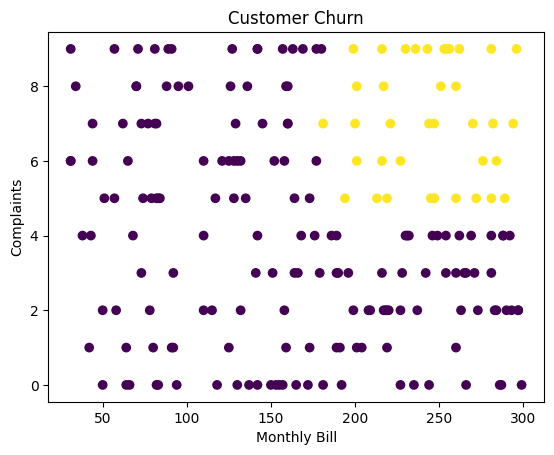

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    df['monthly_bill'],
    df['complaints'],
    c=df['churn']
)

plt.xlabel("Monthly Bill")
plt.ylabel("Complaints")
plt.title("Customer Churn")

plt.show()

## Step 3 – Build Model

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['monthly_bill', 'complaints']]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

## Step 4 – Predict

In [4]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 0 1 0 0 0 0]


## Step 5 – Evaluate

In [5]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.94


## Step 6 – Confusion Matrix

In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[43  1]
 [ 2  4]]


## Summary
Input:
- Monthly Bill
- Complaints

Output:
- Churn or Stay

Goal:
Predict a category

## Note : Logistic Regression does not create a regression line. It creates a classification boundary.

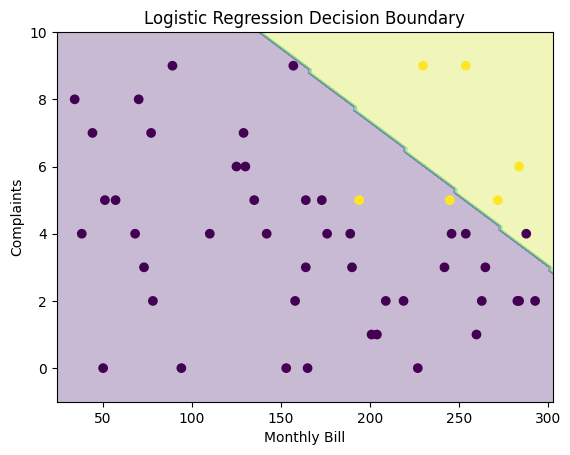

In [7]:
# ==========================================
# Logistic Regression Decision Boundary
# ==========================================

import matplotlib.pyplot as plt


# Create grid
x_min = X_test['monthly_bill'].min()-10
x_max = X_test['monthly_bill'].max()+10

y_min = X_test['complaints'].min()-1
y_max = X_test['complaints'].max()+1


xx, yy = np.meshgrid(
    np.linspace(x_min,x_max,100),
    np.linspace(y_min,y_max,100)
)


# Predict every point
grid = pd.DataFrame({
    'monthly_bill':xx.ravel(),
    'complaints':yy.ravel()
})


Z = model.predict(grid)

Z = Z.reshape(xx.shape)


# Plot boundary

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)


# Plot customers

plt.scatter(
    X_test['monthly_bill'],
    X_test['complaints'],
    c=y_test
)


plt.xlabel(
    "Monthly Bill"
)

plt.ylabel(
    "Complaints"
)

plt.title(
    "Logistic Regression Decision Boundary"
)


plt.show()

High Bill
    |
    |       Churn
    |     ● ● ●
----|----------------
    |
    |  Stay
    | ● ● ●
    |
    +------------------
        Complaints

Meaning:

The line separates:

Likely Stay  |  Likely Churn